# Data gathering and preprocessing

## Imports

In [90]:
import kagglehub
import pandas as pd
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Download latest version
# kagglehub.dataset_download("jessemostipak/hotel-booking-demand", output_dir="./Dataset")
# ds = pd.read_csv("./Dataset/hotel_bookings.csv").sample(30000, random_state=268555)
ds = pd.read_csv("./Dataset/hotel_bookings.csv")

## Data checks

### Understanding given data

In [69]:
ds.info()

def printMissingDataSummary(ds):
    missingCount = ds.isna().sum()
    missingPercentage = (missingCount / len(ds) * 100).round(2)

    missingSummary = pd.DataFrame({
        "missingCount": missingCount,
        "missingPercentage": missingPercentage
    })

    print("\nMissing data summary:")
    print(missingSummary)

printMissingDataSummary(ds)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

### Dealing with missing data #1

In [70]:
ds.drop(columns=["company"], inplace=True)
ds = ds.loc[ds["country"].notna()].copy()
ds = ds.loc[ds["children"].notna()].copy()

### Dealing with strings in data (optional)

In [91]:
def dataframeToNumbers(ds):
    numericDs = ds.copy()

    month_map = {
        'January': 1, 'February': 2, 'March': 3, 'April': 4,
        'May': 5, 'June': 6, 'July': 7, 'August': 8,
        'September': 9, 'October': 10, 'November': 11, 'December': 12
    }

    if 'arrival_date_month' in numericDs.columns:
        if numericDs['arrival_date_month'].dtype == 'object':
            numericDs['arrival_date_month'] = numericDs['arrival_date_month'].map(month_map)
        numericDs['arrival_date_month'] = pd.to_numeric(numericDs['arrival_date_month'], errors='coerce')

    for col in numericDs.select_dtypes(include=['object']).columns:
        if col != 'reservation_status_date':
            numericDs[col] = numericDs[col].astype('category').cat.codes
        else:
            numericDs['reservation_status_date'] = pd.to_datetime(numericDs['reservation_status_date'], errors='coerce')

    return numericDs

sourceDs = ds
if 'arrival_date_month' not in sourceDs.columns and 'baseDs' in globals() and 'arrival_date_month' in baseDs.columns:
    sourceDs = baseDs.copy()

baseDs = sourceDs.copy()
ds = dataframeToNumbers(sourceDs)

### Dealing with time in data

In [92]:
timeDs = ds
required_cols = ['arrival_date_year', 'arrival_date_month', 'arrival_date_day_of_month']

if not all(col in timeDs.columns for col in required_cols) and 'baseDs' in globals():
    if all(col in baseDs.columns for col in required_cols):
        timeDs = baseDs.copy()

ds = timeDs.copy()
ds['arrival_date'] = pd.to_datetime(
    {
        'year': ds['arrival_date_year'],
        'month': ds['arrival_date_month'],
        'day': ds['arrival_date_day_of_month']
    },
    errors='coerce'
)

ds = ds[ds['arrival_date'].notna()].copy()

ds.drop(columns=['arrival_date_year', 'arrival_date_month', 'arrival_date_day_of_month'], inplace=True)

### Dealing with orphans

In [73]:
ds = ds[ds['adults'] != 0]

### Dealing with missing data #2

In [74]:
trainDf = ds[ds["agent"].notna()].copy()
predictDf = ds[ds["agent"].isna()].copy()

y = trainDf["agent"]
X = trainDf.drop(columns=["agent"])
predX = predictDf.drop(columns=["agent"])

catCols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numCols = X.select_dtypes(include=["number"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", sklearn.preprocessing.OneHotEncoder(handle_unknown="ignore"), catCols),
        ("num", "passthrough", numCols),
    ]
)

model = sklearn.pipeline.Pipeline([
    ("pre", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=268555))
])

trainX, valX, trainY, valY = sklearn.model_selection.train_test_split(X, y, test_size=0.2, random_state=268555)

model.fit(trainX, trainY)
print("val score:", model.score(valX, valY))

predictedAgents = model.predict(predX)

ds.loc[ds["agent"].isna(), "agent"] = predictedAgents

val score: 0.8819564894196937


In [75]:
printMissingDataSummary(ds)


Missing data summary:
                                missingCount  missingPercentage
hotel                                      0                0.0
is_canceled                                0                0.0
lead_time                                  0                0.0
arrival_date_week_number                   0                0.0
stays_in_weekend_nights                    0                0.0
stays_in_week_nights                       0                0.0
adults                                     0                0.0
children                                   0                0.0
babies                                     0                0.0
meal                                       0                0.0
country                                    0                0.0
market_segment                             0                0.0
distribution_channel                       0                0.0
is_repeated_guest                          0                0.0
previous_cancella

In [76]:
def printColumnValueCounts(ds):
    print(ds.nunique(dropna=False))

    rows = []
    for col in ds.columns:
        counts = ds[col].value_counts(dropna=False).sort_values(ascending=False)
        for val, cnt in counts.items():
            rows.append({
                "column": col,
                "value": str(val),
                "count": cnt
            })

    result = pd.DataFrame(rows)
    result.to_csv("./Dataset/column_value_counts.csv", index=False, encoding="utf-8-sig")
    print("Wrote", len(result), "rows to column_value_counts.csv")

printColumnValueCounts(ds)

hotel                                2
is_canceled                          2
lead_time                          475
arrival_date_week_number            53
stays_in_weekend_nights             15
stays_in_week_nights                31
adults                              13
children                             5
babies                               5
meal                                 5
country                            175
market_segment                       7
distribution_channel                 5
is_repeated_guest                    2
previous_cancellations              15
previous_bookings_not_canceled      72
reserved_room_type                   9
assigned_room_type                  11
booking_changes                     19
deposit_type                         3
agent                              332
days_in_waiting_list               127
customer_type                        4
adr                               8698
required_car_parking_spaces          5
total_of_special_requests

### Correlation matrix presentation

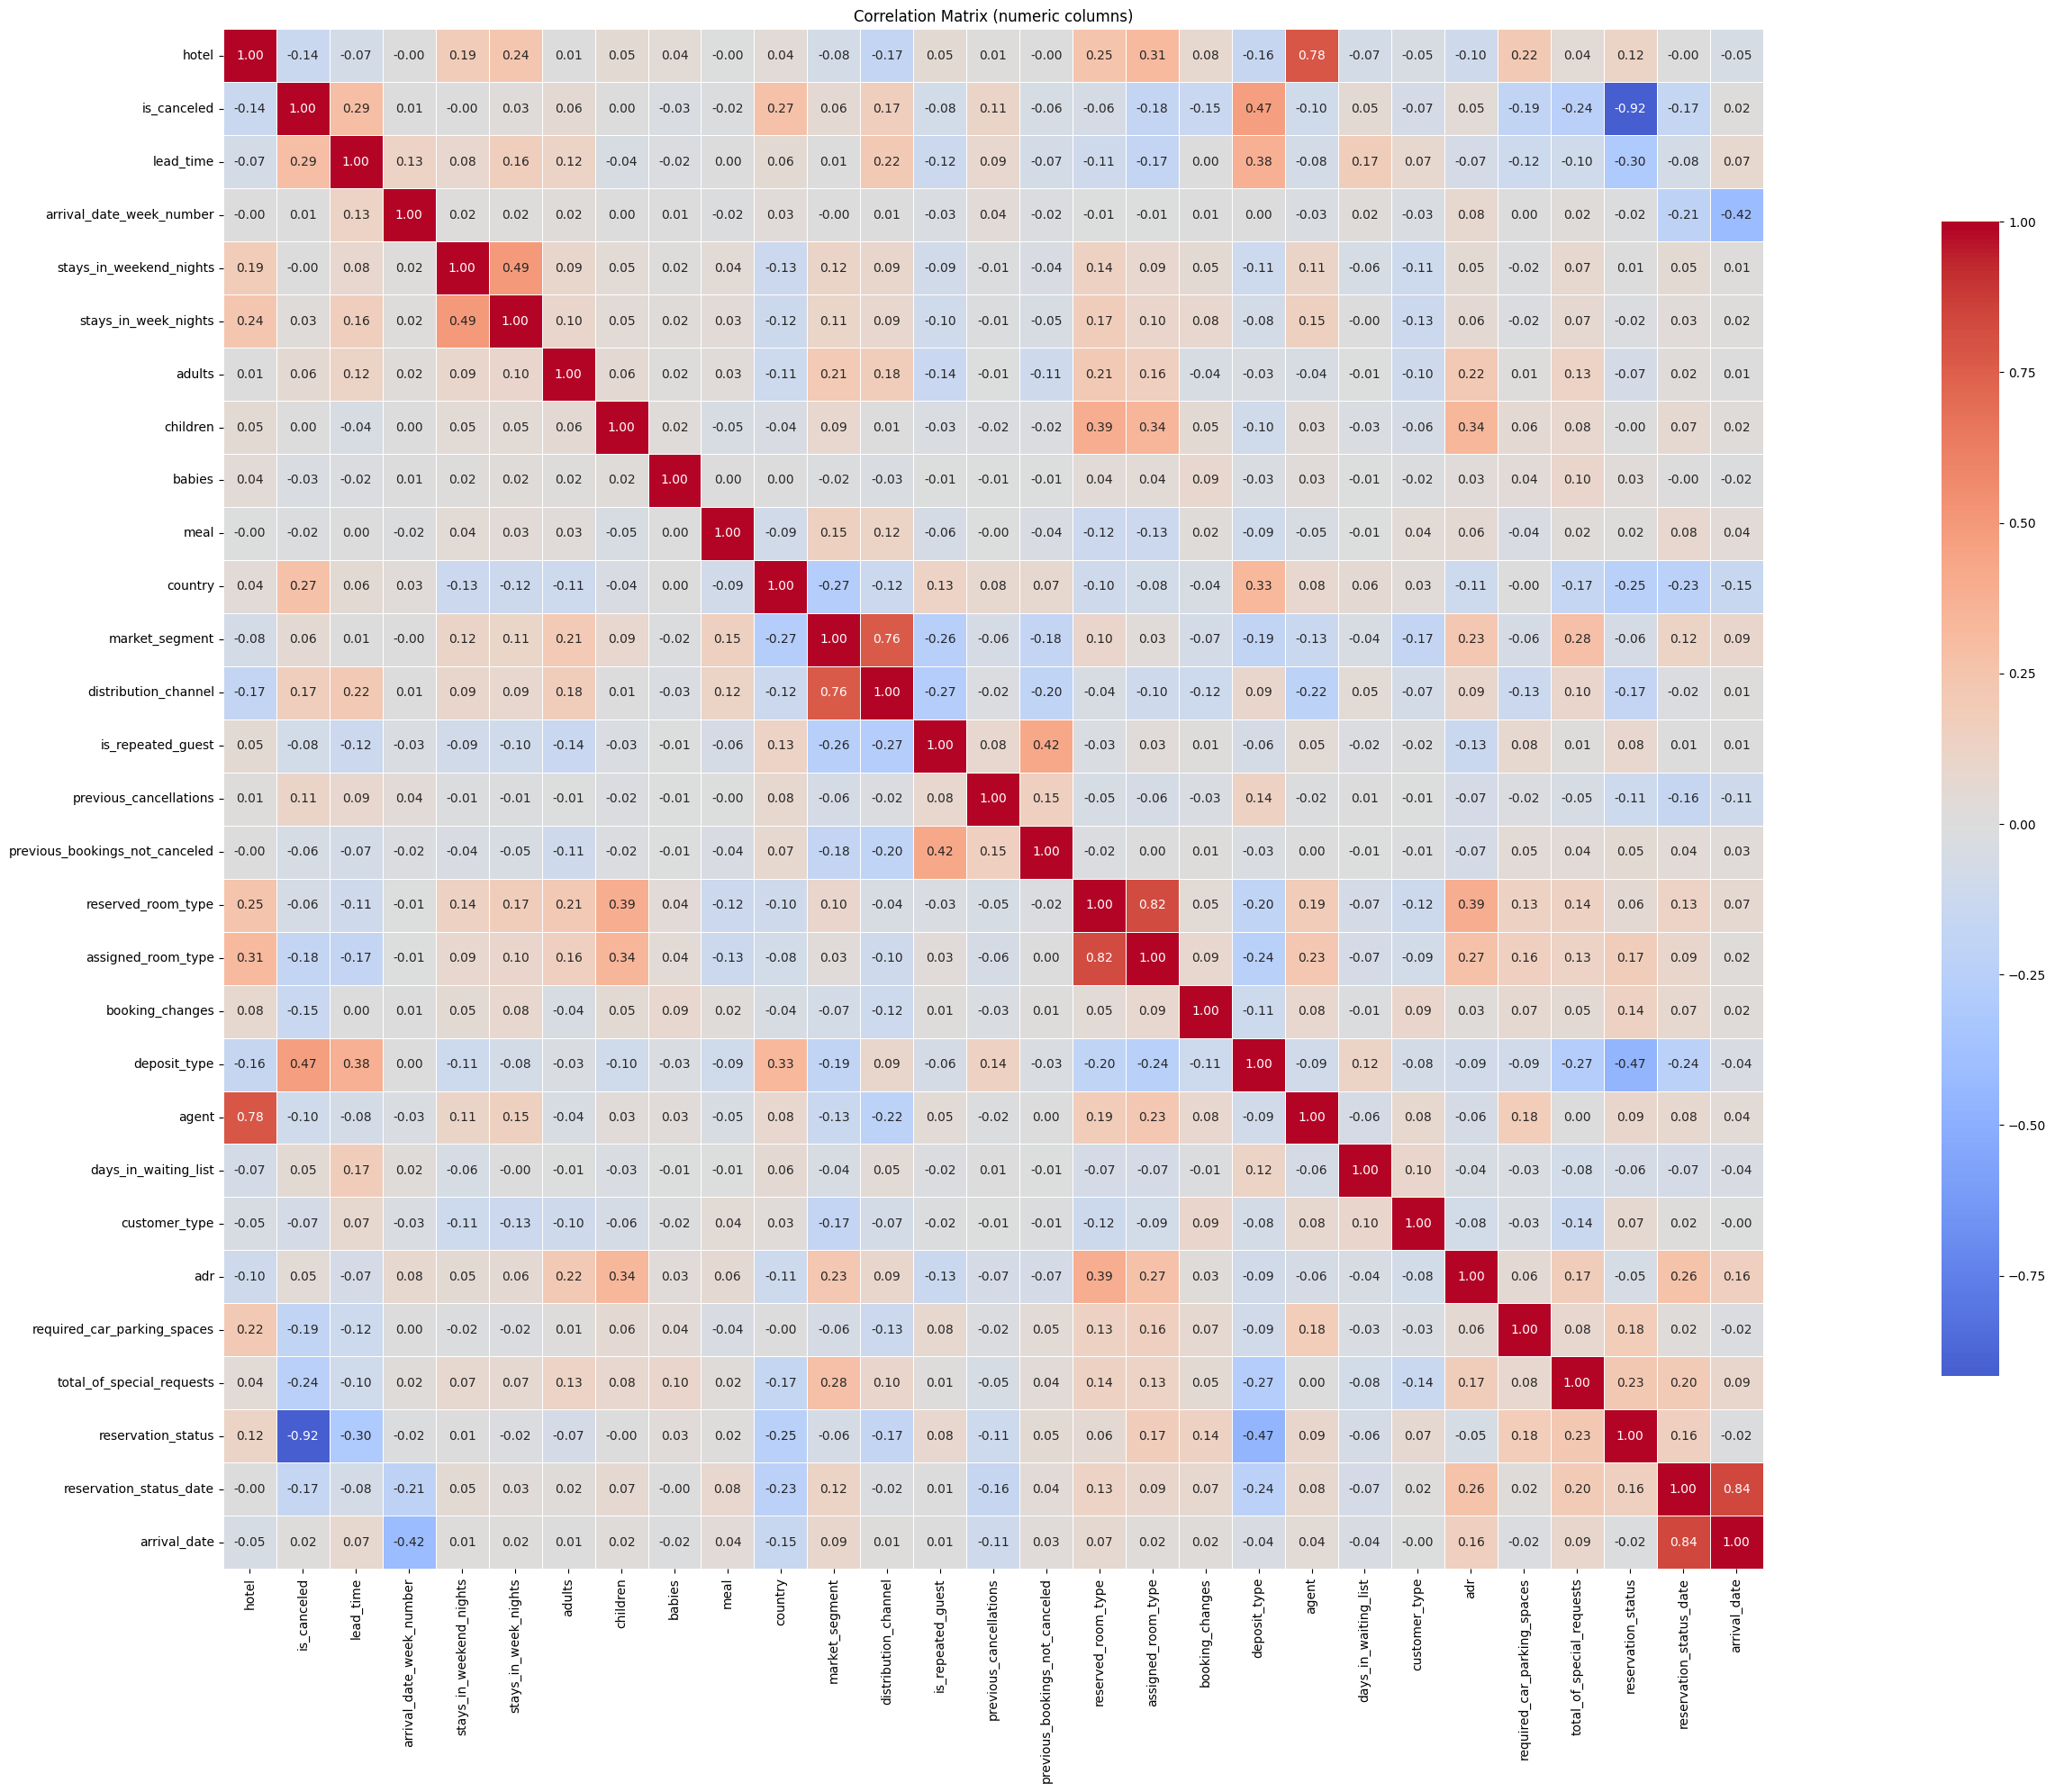

In [77]:
def printComputationMatrix(ds):
    corr = ds.corr()

    plt.figure(figsize=(40, 20))
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.75}
    )
    plt.title("Correlation Matrix (numeric columns)")
    plt.tight_layout()
plt.show()

printComputationMatrix(ds)

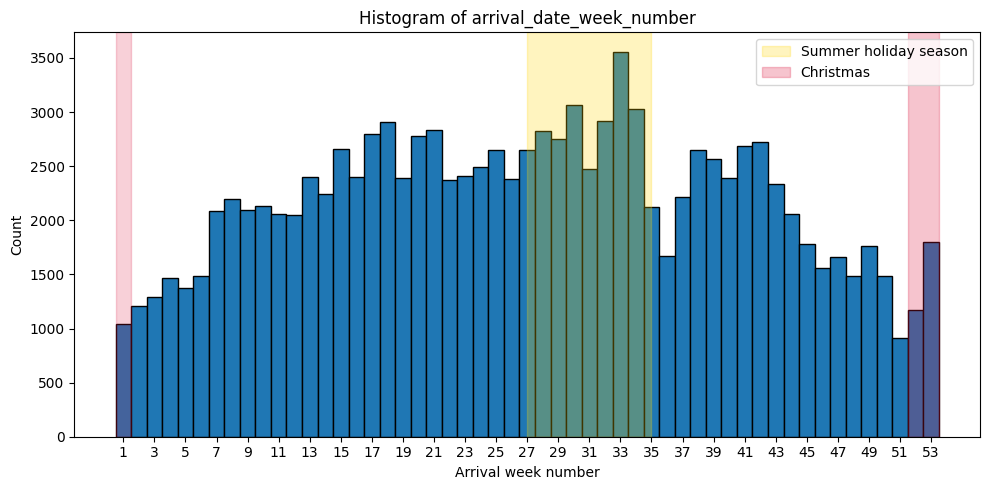

In [83]:
week_numbers = ds['arrival_date_week_number'].dropna()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(week_numbers, bins=53, range=(0.5, 53.5), edgecolor='black', color='#1f77b4')

# Week range approximation: July-August is usually weeks 27-35.
ax.axvspan(27, 35, color='gold', alpha=0.25, label='Summer holiday season')
# Christmas is concentrated around ISO week 52.
ax.axvspan(51.5, 53.5, color='crimson', alpha=0.25, label='Christmas')
ax.axvspan(0.5, 1.5, color='crimson', alpha=0.2, label='_nolegend_')

ax.set_title('Histogram of arrival_date_week_number')
ax.set_xlabel('Arrival week number')
ax.set_ylabel('Count')
ax.set_xticks(range(1, 54, 2))
ax.legend()
plt.tight_layout()
plt.show()

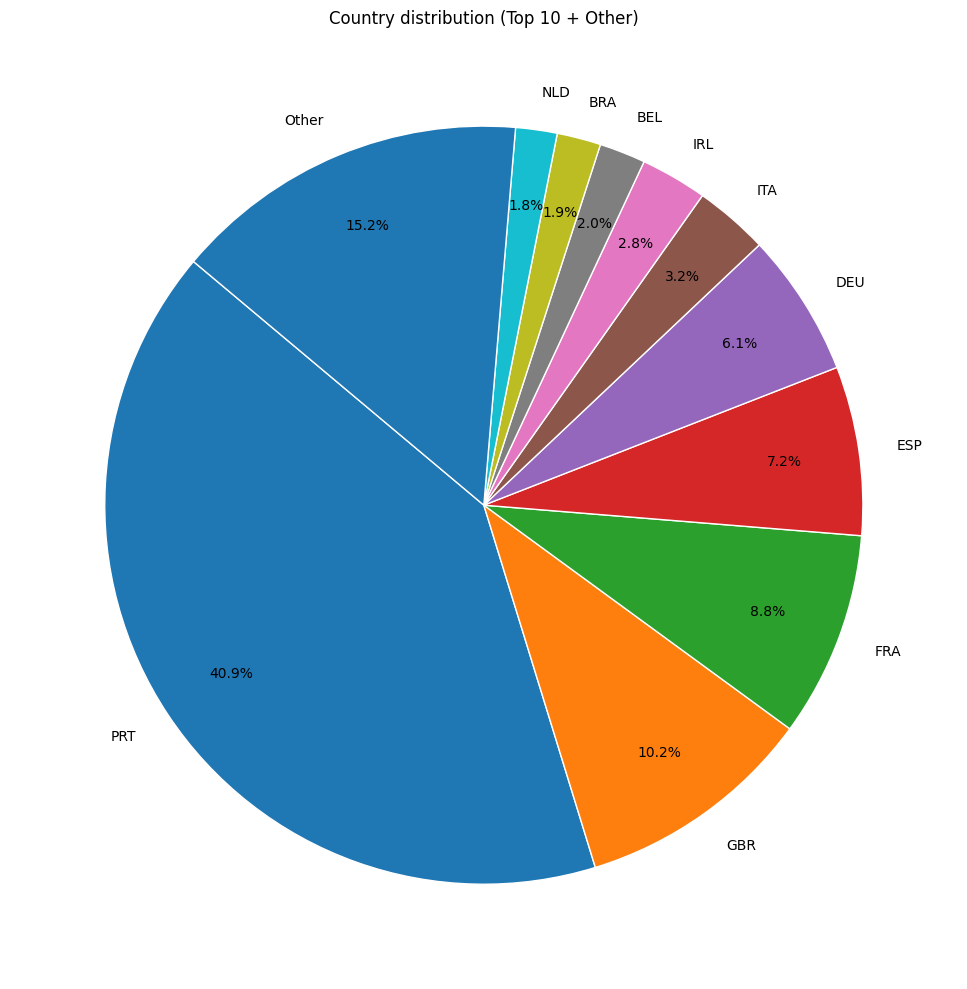

In [79]:
country_counts = baseDs['country'].value_counts()
top_n = 10
top_counts = country_counts.head(top_n).copy()
other_count = country_counts.iloc[top_n:].sum()

if other_count > 0:
    top_counts.loc['Other'] = other_count

plt.figure(figsize=(10, 10))
plt.pie(
    top_counts,
    labels=top_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.8,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)
plt.title('Country distribution (Top 10 + Other)')
plt.tight_layout()
plt.show()

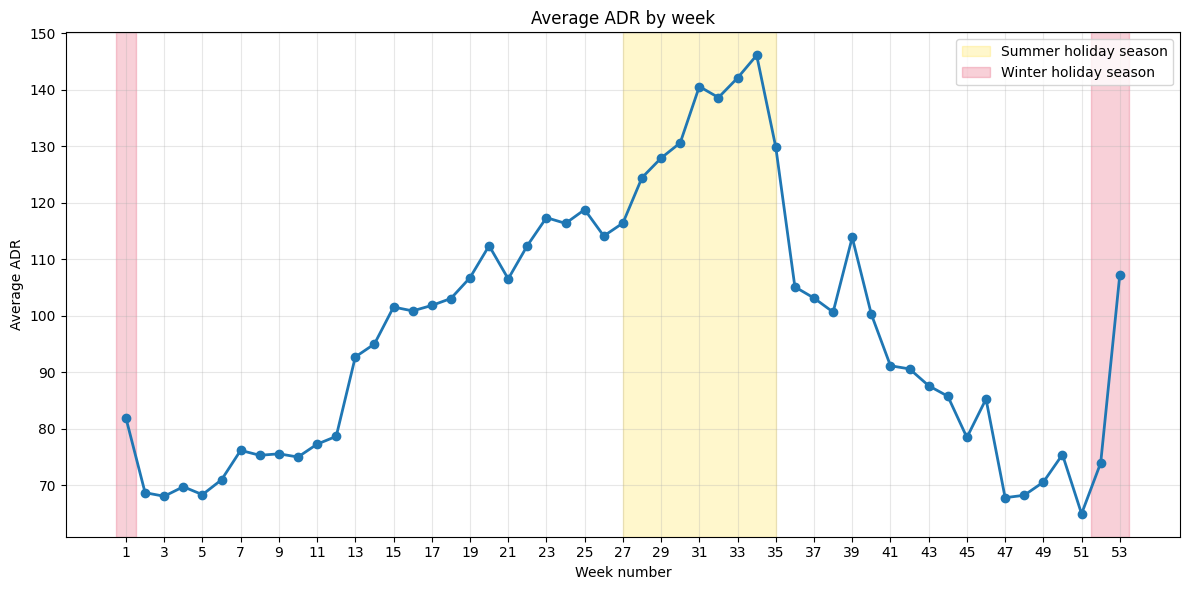

In [80]:
avg_adr_by_week = ds.groupby('arrival_date_week_number')['adr'].mean().sort_index()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(avg_adr_by_week.index, avg_adr_by_week.values, marker='o', linewidth=2)

# Week range approximation: July-August is usually weeks 27-35.
ax.axvspan(27, 35, color='gold', alpha=0.2, label='Summer holiday season')
# Christmas season wraps around year-end: 51.5 -> 1.5.
ax.axvspan(51.5, 53.5, color='crimson', alpha=0.2, label='Winter holiday season')
ax.axvspan(0.5, 1.5, color='crimson', alpha=0.2, label='_nolegend_')

ax.set_title('Average ADR by week')
ax.set_xlabel('Week number')
ax.set_ylabel('Average ADR')
ax.set_xticks(range(1, 54, 2))
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

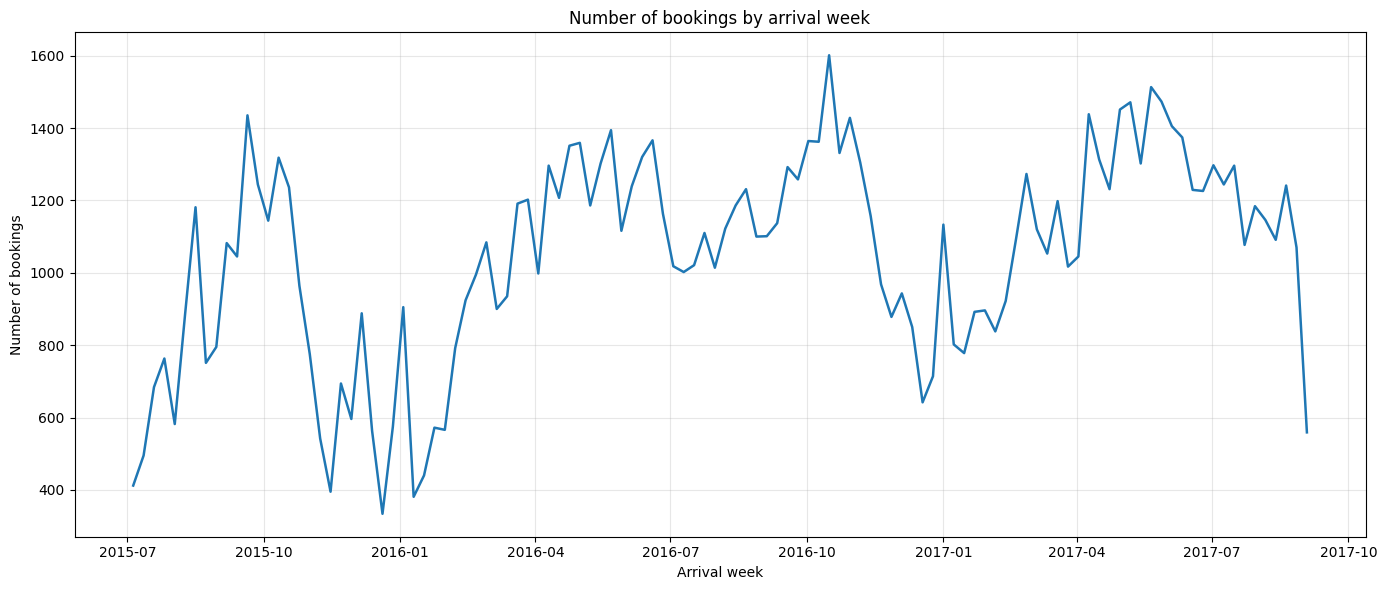

In [93]:
arrival_week_counts = ds.set_index('arrival_date').resample('W').size()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(arrival_week_counts.index, arrival_week_counts.values, linewidth=1.8)
ax.set_title('Number of bookings by arrival week')
ax.set_xlabel('Arrival week')
ax.set_ylabel('Number of bookings')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()